# Bias–Variance Trade-off — An Illustrated Tour

Every prediction error of a model fit to noisy data decomposes into three pieces:

$$\mathbb{E}\bigl[(y - \hat f(x))^2\bigr] \;=\; \underbrace{\bigl(\mathbb{E}[\hat f(x)] - f(x)\bigr)^2}_{\text{bias}^2} \;+\; \underbrace{\mathbb{E}\bigl[\hat f(x) - \mathbb{E}[\hat f(x)]\bigr]^2}_{\text{variance}} \;+\; \underbrace{\sigma^2}_{\text{irreducible}}$$

We will *measure each piece* by simulating many fits to many fresh training sets.

| Term | Plain meaning | Caused by |
|---|---|---|
| **Bias** | The *average* prediction is wrong | Model too simple — can't represent the truth |
| **Variance** | The prediction *changes a lot* between training sets | Model too flexible — chases noise |
| **Irreducible** | Pure noise in the labels | Noisy measurements, missing features |


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

rng = np.random.RandomState(0)
def f_true(x): return np.sin(1.5*x) + 0.3*x
sigma = 0.4
n = 30
x_test = np.linspace(0, 5, 200)
y_test_true = f_true(x_test)

def make_dataset(seed):
    r = np.random.RandomState(seed)
    x = r.uniform(0, 5, n)
    y = f_true(x) + sigma*r.randn(n)
    return x[:, None], y
print('Set up: n=30 train points, 200 test points, sigma =', sigma)


Set up: n=30 train points, 200 test points, sigma = 0.4


---
## How `PolynomialFeatures` + `LinearRegression` builds a polynomial model

`PolynomialFeatures(d)` is a **feature transformer** — it takes a single input $x$ and expands it into $d+1$ terms:

$$x \;\xrightarrow{\text{degree}=d}\; \bigl[1,\; x,\; x^2,\; \ldots,\; x^d\bigr]$$

Feeding these into `LinearRegression` finds weights $\theta_0, \ldots, \theta_d$ that minimise squared error, which is exactly fitting a degree-$d$ polynomial:

$$\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \cdots + \theta_d x^d$$

`make_pipeline(PolynomialFeatures(d), LinearRegression)` chains both steps so `.fit(X, y)` and `.predict(X)` handle the feature expansion automatically — no manual bookkeeping.

**Why degree is the complexity knob:**

| Degree | # parameters | What it can represent |
|---|---|---|
| 1 | 2 | Straight line — rigid, high bias |
| 3 | 4 | Cubic — mild curvature |
| 15 | 16 | Can thread through almost every training point — low bias, high variance |

Increasing degree expands the **hypothesis class** (everything the model *can* fit), which reduces bias but gives the model more ways to chase noise — raising variance. This is the handle we turn in the experiments below.

---
## Statistical Moments — Foundation for Bias & Variance

Before measuring bias and variance, we need the vocabulary of **statistical moments**.
A moment summarises the shape of a distribution in a single number.

### 1st Moment — Mean (Expected Value)
$$\mu = \mathbb{E}[X] = \frac{1}{n}\sum_{i=1}^{n} x_i$$

**In the bias-variance context**, the random variable is the model's prediction $\hat{f}(x;\,\hat{\theta})$ at a fixed test point $x$.
The randomness comes from the training set $\mathcal{D}$ — each draw of $\mathcal{D}$ produces a different $\hat{\theta}$, so the expectation is:

$$\mathbb{E}_{\mathcal{D}}\bigl[\hat{f}(x;\,\hat{\theta}(\mathcal{D}))\bigr]$$

This is the **average prediction across all possible training sets**, which is the same as averaging over the distribution of learned $\hat{\theta}$.
**Bias** is the gap between this average and the truth $f(x)$:

$$\text{bias}(x) = \mathbb{E}_{\mathcal{D}}\bigl[\hat{f}(x;\,\hat{\theta}(\mathcal{D}))\bigr] - f(x)$$

> Key point: the mean and bias are **not** over data points in one training set — they are over *different training sets*, each producing its own $\hat{\theta}$.

---

### 2nd Moment — Variance (Spread)

The **raw 2nd moment** is $\mathbb{E}[X^2]$.
More useful is the **2nd central moment** (variance):
$$\sigma^2 = \mathbb{E}\bigl[(X - \mu)^2\bigr] = \frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2$$

In the bias-variance context, this is the variance of the prediction $\hat{f}(x;\,\hat{\theta})$ across different training sets:

$$\text{Var}(x) = \mathbb{E}_{\mathcal{D}}\Bigl[\bigl(\hat{f}(x;\,\hat{\theta}(\mathcal{D})) - \mathbb{E}_{\mathcal{D}}[\hat{f}(x;\,\hat{\theta}(\mathcal{D}))]\bigr)^2\Bigr]$$

How much does $\hat{\theta}$ *move* when you swap training sets? That movement at prediction time is the variance term.

---

### With 2 features: Mean Vector & Covariance Matrix

When $\mathbf{x} \in \mathbb{R}^2$, the 1st moment becomes a **mean vector** and the 2nd central moment becomes a **2×2 covariance matrix**:

$$\boldsymbol{\mu} = \mathbb{E}[\mathbf{x}], \qquad \Sigma = \mathbb{E}\bigl[(\mathbf{x}-\boldsymbol{\mu})(\mathbf{x}-\boldsymbol{\mu})^\top\bigr] = \begin{pmatrix}\sigma_1^2 & \sigma_{12} \\ \sigma_{12} & \sigma_2^2\end{pmatrix}$$

- **Diagonal entries** $\sigma_1^2, \sigma_2^2$ — variance of each feature individually.
- **Off-diagonal** $\sigma_{12}$ — how the two features co-vary (positive → move together, negative → move oppositely).

The covariance matrix can be visualised as an **ellipse**: axes align with the eigenvectors of $\Sigma$, scaled by $\sqrt{\lambda_i}$.


Class A:
  1st moment  μ  = [1.597, 2.083]
  2nd moment  Σ  =
[[0.507 0.313]
 [0.313 0.406]]

Class B:
  1st moment  μ  = [3.463, 1.122]
  2nd moment  Σ  =
[[ 0.529 -0.32 ]
 [-0.32   0.77 ]]



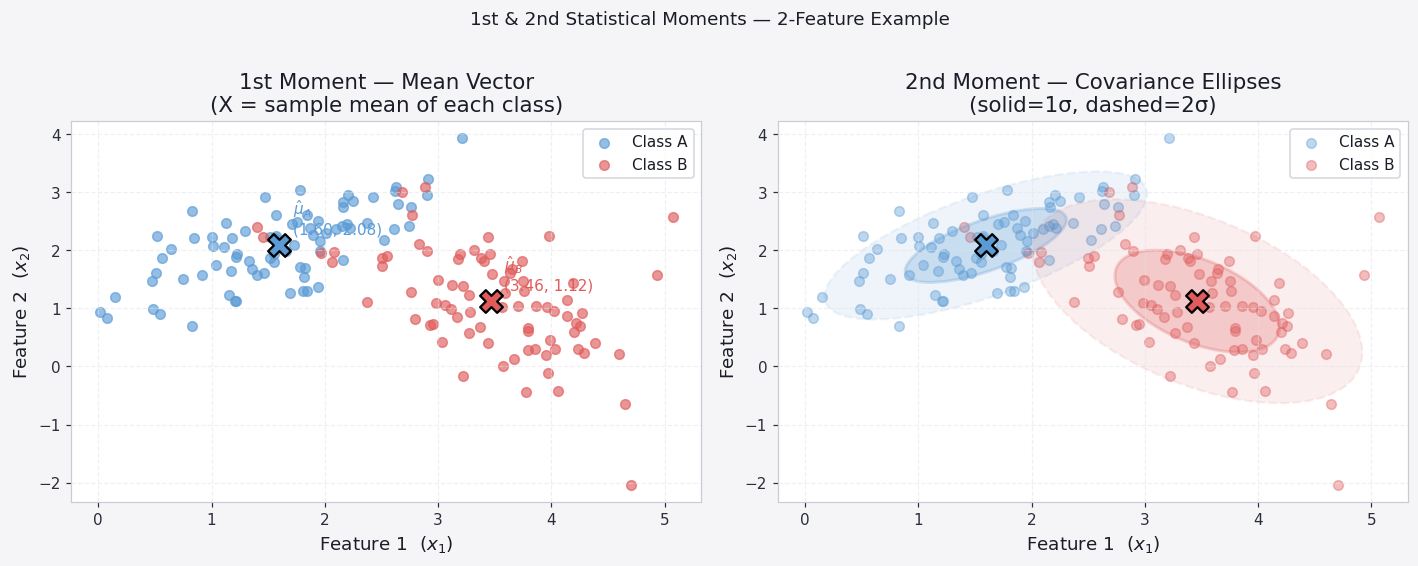

In [33]:
from matplotlib.patches import Ellipse

rng2 = np.random.RandomState(42)

# Two 2-feature classes with different means and covariances
mean_A = np.array([1.5, 2.0])
mean_B = np.array([3.5, 1.0])
cov_A  = np.array([[0.6,  0.4], [ 0.4, 0.5]])   # positively correlated
cov_B  = np.array([[0.5, -0.3], [-0.3, 0.8]])   # negatively correlated

n_pts = 80
X_A = rng2.multivariate_normal(mean_A, cov_A, n_pts)
X_B = rng2.multivariate_normal(mean_B, cov_B, n_pts)

def cov_ellipse(mean, cov, ax, n_std, **kwargs):
    """Draw a covariance ellipse aligned to eigenvectors of cov."""
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h = 2 * n_std * np.sqrt(vals)
    ax.add_patch(Ellipse(xy=mean, width=w, height=h, angle=angle, **kwargs))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left panel: 1st moment (mean vector) ──────────────────────────────────
ax = axes[0]
ax.scatter(X_A[:, 0], X_A[:, 1], color=PALETTE[0], s=40, alpha=0.65, label='Class A')
ax.scatter(X_B[:, 0], X_B[:, 1], color=PALETTE[1], s=40, alpha=0.65, label='Class B')

for X, c, name in [(X_A, PALETTE[0], 'A'), (X_B, PALETTE[1], 'B')]:
    mu = X.mean(axis=0)              # 1st moment
    ax.scatter(*mu, marker='X', s=220, color=c, edgecolors='black',
               linewidth=1.5, zorder=6)
    ax.annotate(f'$\\hat{{\\mu}}_{{{name}}}$\n({mu[0]:.2f}, {mu[1]:.2f})',
                xy=mu, xytext=(mu[0] + 0.12, mu[1] + 0.20),
                fontsize=10, color=c)

ax.set_xlabel('Feature 1  ($x_1$)')
ax.set_ylabel('Feature 2  ($x_2$)')
ax.set_title('1st Moment — Mean Vector\n(X = sample mean of each class)')
ax.legend(); ax.grid(True)

# ── Right panel: 2nd moment (covariance ellipses) ─────────────────────────
ax = axes[1]
ax.scatter(X_A[:, 0], X_A[:, 1], color=PALETTE[0], s=40, alpha=0.40, label='Class A')
ax.scatter(X_B[:, 0], X_B[:, 1], color=PALETTE[1], s=40, alpha=0.40, label='Class B')

for X, c, name in [(X_A, PALETTE[0], 'A'), (X_B, PALETTE[1], 'B')]:
    mu      = X.mean(axis=0)         # 1st moment
    cov_hat = np.cov(X.T)            # 2nd central moment matrix
    ax.scatter(*mu, marker='X', s=220, color=c, edgecolors='black',
               linewidth=1.5, zorder=6)
    # 1σ and 2σ ellipses from the covariance matrix
    cov_ellipse(mu, cov_hat, ax, n_std=1, facecolor=c, alpha=0.25, edgecolor=c, lw=2)
    cov_ellipse(mu, cov_hat, ax, n_std=2, facecolor=c, alpha=0.10, edgecolor=c, lw=1.5,
                linestyle='--')
    print(f'Class {name}:')
    print(f'  1st moment  μ  = [{mu[0]:.3f}, {mu[1]:.3f}]')
    print(f'  2nd moment  Σ  =\n{cov_hat.round(3)}')
    print()

ax.set_xlabel('Feature 1  ($x_1$)')
ax.set_ylabel('Feature 2  ($x_2$)')
ax.set_title('2nd Moment — Covariance Ellipses\n(solid=1σ, dashed=2σ)')
ax.legend(); ax.grid(True)

fig.suptitle('1st & 2nd Statistical Moments — 2-Feature Example', y=1.02)
plt.tight_layout(); plt.show()


---
## The dartboard analogy — what bias and variance *look like*

Imagine four archers, each shooting 25 arrows at the bullseye. Each arrow is one model trained on a fresh dataset.

- **Bias** = how far the *centre* of the arrows lands from the bullseye (systematic error).
- **Variance** = how spread out the arrows are around their own centre (instability).


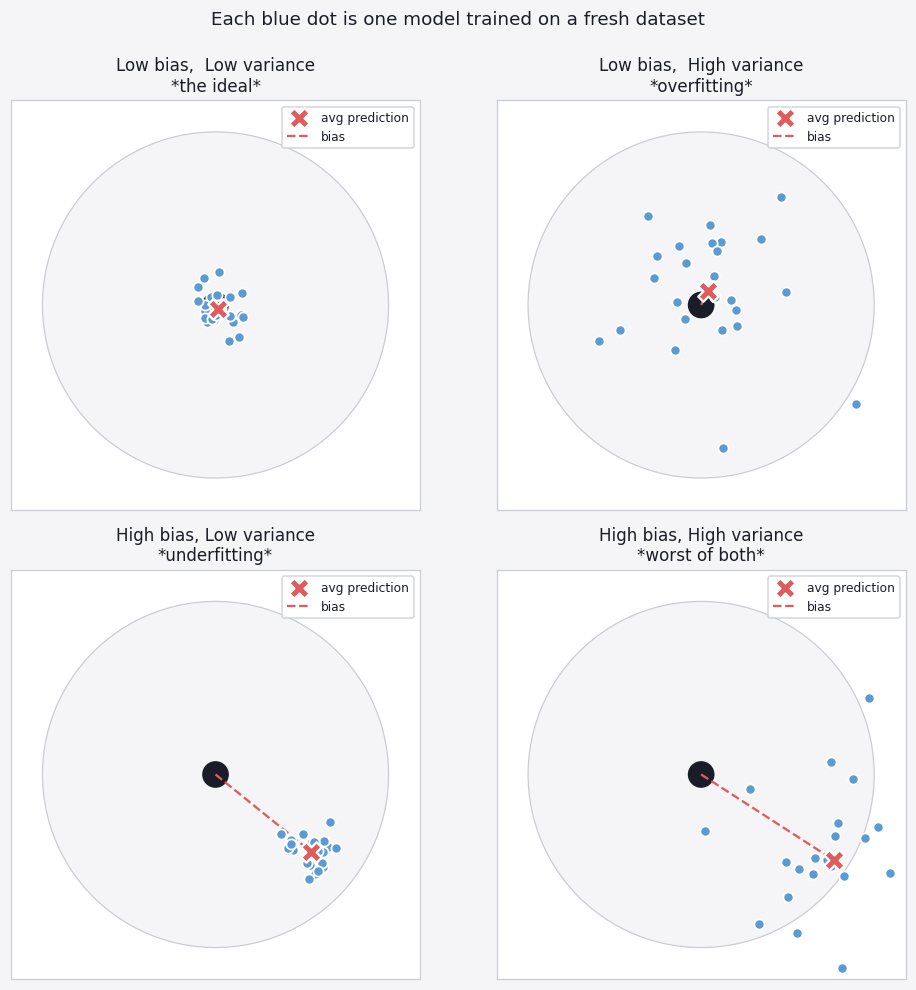

In [37]:
rng = np.random.RandomState(1)
n_shots = 25

def shots(bias_xy, var):
    return np.array(bias_xy) + var*rng.randn(n_shots, 2)

scenarios = [
    ('Low bias,  Low variance',  (0.0,  0.0), 0.10, '*the ideal*'),
    ('Low bias,  High variance', (0.0,  0.0), 0.45, '*overfitting*'),
    ('High bias, Low variance',  (0.6, -0.5), 0.10, '*underfitting*'),
    ('High bias, High variance', (0.6, -0.5), 0.45, '*worst of both*'),
]

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for ax, (title, b, v, sub) in zip(axes.ravel(), scenarios):
    s = shots(b, v)
    # Concentric rings
    for r, c in zip([0.2, 0.5, 0.8, 1.1],
                    ['#fde7e7', '#fbd0d0', '#f7a8a8', '#f5f5f7']):
        ax.add_patch(plt.Circle((0, 0), r, color=c, ec='#c8ccd4', lw=0.8, zorder=0))
    ax.add_patch(plt.Circle((0, 0), 0.08, color='#1a1d27', zorder=1))   # bullseye
    # Arrows
    ax.scatter(s[:,0], s[:,1], color=PALETTE[0], s=45,
               edgecolor='white', linewidth=1.2, zorder=3)
    # Centre of the arrows = average prediction
    centre = s.mean(axis=0)
    ax.scatter(*centre, marker='X', s=180, color=PALETTE[1],
               edgecolor='white', linewidth=1.5, zorder=4,
               label='avg prediction')
    ax.plot([0, centre[0]], [0, centre[1]], color=PALETTE[1],
            ls='--', lw=1.5, zorder=2, label='bias')
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{title}\n{sub}', fontsize=11)
    ax.legend(loc='upper right', fontsize=8)
fig.suptitle('Each blue dot is one model trained on a fresh dataset', y=0.995)
plt.tight_layout(); plt.show()

- **Top-left** (low bias, low variance) — arrows cluster tightly *on* the bullseye. What we want.
- **Top-right** (low bias, high variance) — arrows still *average* to the bullseye, but any single shot can be far off. **Classic overfitting.**
- **Bottom-left** (high bias, low variance) — arrows cluster tightly, but *off* the bullseye. **Classic underfitting.**
- **Bottom-right** (high bias, high variance) — wrong on average *and* unstable. The worst.

Re-read the formula at the top with this picture in mind: $\text{bias}^2$ is the squared distance from the red X to the bullseye; variance is the spread of the blue dots around the red X.


---
## The classic schematic — bias, variance, total error vs complexity

Before we measure anything, here is the *picture* every textbook draws.
As model complexity grows:

- **Bias²** falls (the model can express more shapes).
- **Variance** rises (the model can also chase noise).
- **Total expected error = bias² + variance + irreducible noise** is U-shaped.

The sweet spot is the **minimum of the green curve**. Anything to its left is *underfitting*, anything to its right is *overfitting*.


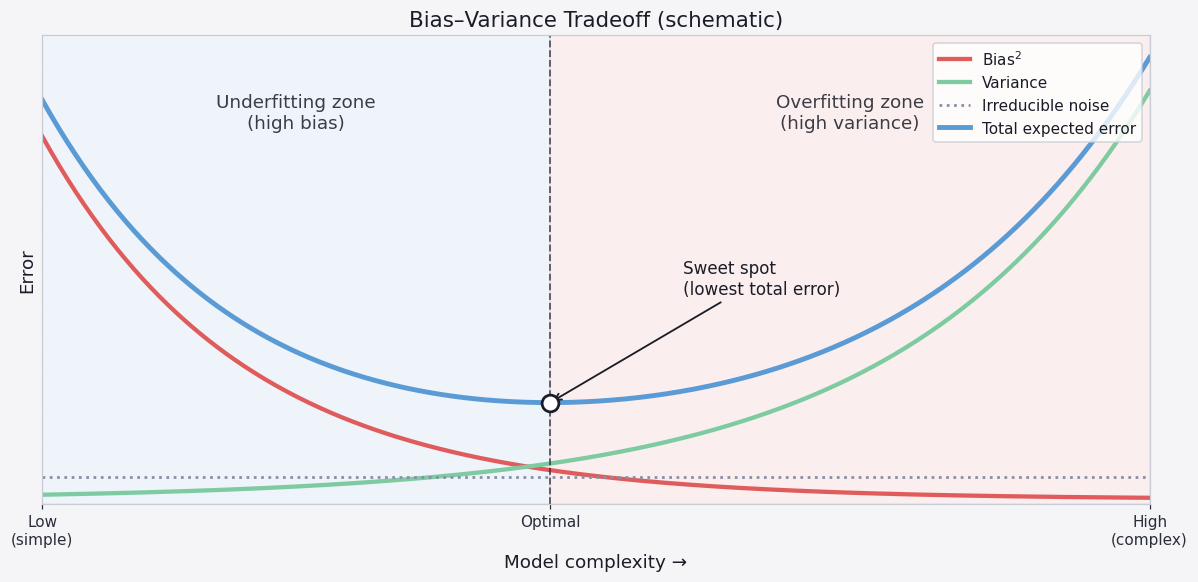

In [38]:
# Conceptual / schematic diagram — not measured, drawn from smooth curves.
c = np.linspace(0, 10, 400)
bias2     = 4.0 * np.exp(-0.55 * c) + 0.05
variance  = 0.05 * np.exp( 0.45 * c) + 0.05
irred     = np.full_like(c, 0.30)
total     = bias2 + variance + irred
opt_idx   = int(np.argmin(total))
opt_c     = c[opt_idx]

fig, ax = plt.subplots(figsize=(11, 5.4))

# Shaded zones
ax.axvspan(c[0],   opt_c, alpha=0.10, color=PALETTE[0], label='_nolegend_')
ax.axvspan(opt_c,  c[-1], alpha=0.10, color=PALETTE[1], label='_nolegend_')
ax.text(opt_c/2,        total.max()*0.92, 'Underfitting zone\n(high bias)',
        ha='center', va='top', fontsize=12, color='#1a1d27', alpha=0.85)
ax.text((opt_c+c[-1])/2, total.max()*0.92, 'Overfitting zone\n(high variance)',
        ha='center', va='top', fontsize=12, color='#1a1d27', alpha=0.85)

# Curves
ax.plot(c, bias2,    color=PALETTE[1], lw=2.8, label='Bias$^2$')
ax.plot(c, variance, color=PALETTE[3], lw=2.8, label='Variance')
ax.plot(c, irred,    color='#888fa5',  lw=1.8, ls=':', label='Irreducible noise')
ax.plot(c, total,    color=PALETTE[0], lw=3.2, label='Total expected error')

# Sweet-spot marker
ax.axvline(opt_c, color='#1a1d27', ls='--', lw=1.2, alpha=0.7)
ax.scatter([opt_c], [total[opt_idx]], color='white',
           edgecolor='#1a1d27', s=120, lw=1.8, zorder=6)
ax.annotate('Sweet spot\n(lowest total error)',
            xy=(opt_c, total[opt_idx]),
            xytext=(opt_c + 1.2, total[opt_idx] + 1.2),
            fontsize=11, ha='left',
            arrowprops=dict(arrowstyle='->', color='#1a1d27', lw=1.2))

ax.set_xlim(0, 10); ax.set_ylim(0, total.max()*1.05)
ax.set_xlabel('Model complexity →')
ax.set_ylabel('Error')
ax.set_xticks([0, opt_c, 10])
ax.set_xticklabels(['Low\n(simple)', 'Optimal', 'High\n(complex)'])
ax.set_yticks([])
ax.set_title('Bias–Variance Tradeoff (schematic)')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## Three model flexibilities on five fresh training sets

A flat (degree-1) model is rigid → high bias, low variance.
A wiggly (degree-15) model bends to noise → low bias, high variance.


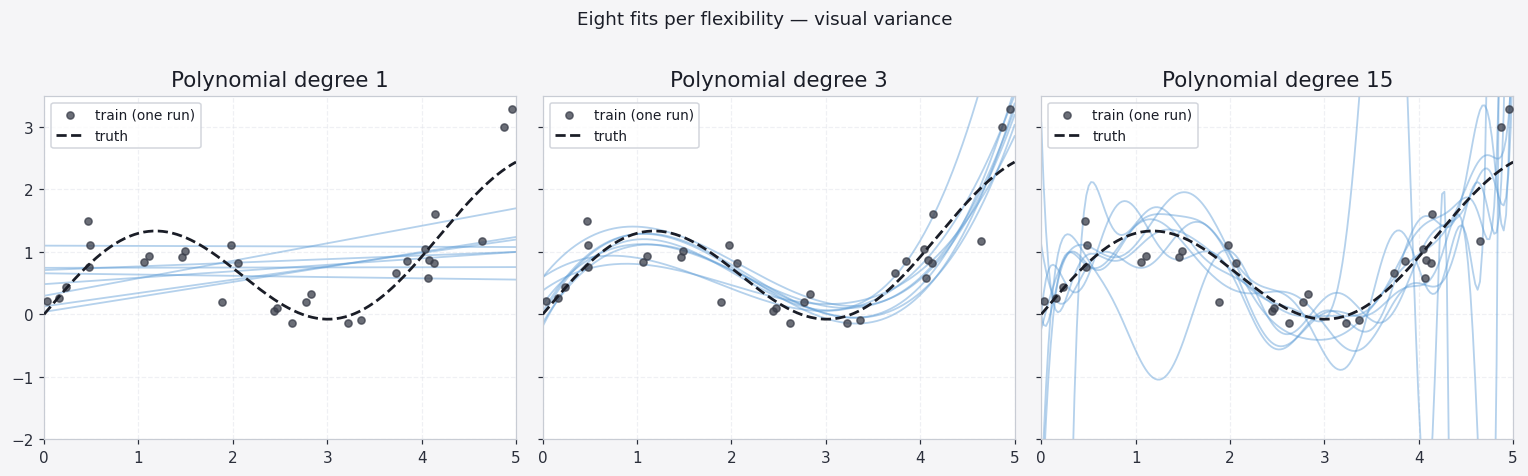

In [39]:
degrees = [1, 3, 15]
n_runs  = 50

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, d in zip(axes, degrees):
    for run in range(8):
        X, y = make_dataset(run)
        m = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(X, y)
        ax.plot(x_test, m.predict(x_test[:, None]),
                color=PALETTE[0], alpha=0.45, lw=1.2)
    X, y = make_dataset(99)
    ax.scatter(X.ravel(), y, s=22, color='#3a3e4a', alpha=0.75,
               zorder=5, label='train (one run)')
    ax.plot(x_test, y_test_true, color='#1a1d27', lw=1.8, ls='--',
            zorder=6, label='truth')
    ax.set_title(f'Polynomial degree {d}')
    ax.set_xlim(0, 5)
    ax.grid(True); ax.legend(loc='upper left', fontsize=9)
axes[0].set_ylim(-2.0, 3.5)   # clip wild degree-15 extrapolations so all panels are readable
fig.suptitle('Eight fits per flexibility — visual variance', y=1.02)
fig.tight_layout(); plt.show()


---
## The classical U-shaped curve

Repeat the experiment over a range of polynomial degrees and 50 fresh training sets.
At each test point compute mean prediction (for bias²) and prediction variance.


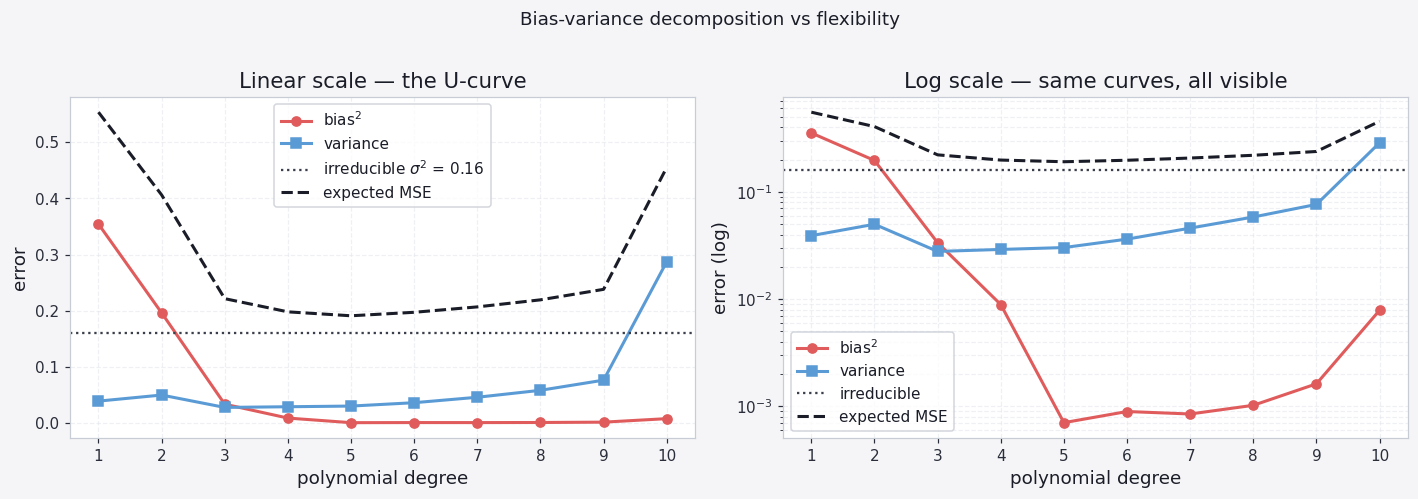

Lowest expected MSE at degree d = 5
  bias^2 at d=1  : 0.354   (high-bias regime)
  variance at d=1: 0.039
  bias^2 at d=5  : 0.001   (sweet spot)
  variance at d=5: 0.030
  bias^2 at d=10 : 0.008   (high-variance regime)
  variance at d=10: 0.287


In [40]:
degs = list(range(1, 11))   # degrees 11+ explode (variance ~10^6) and hide the trade-off
bias2, var, total = [], [], []
# Restrict evaluation to the *interior* of the training range so wild edge
# extrapolation from high-degree polynomials does not dominate the error bars.
mask = (x_test >= 0.5) & (x_test <= 4.5)
xt   = x_test[mask]
yt   = y_test_true[mask]

for d in degs:
    preds = np.zeros((n_runs, len(xt)))
    for run in range(n_runs):
        X, y = make_dataset(run)
        m = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(X, y)
        preds[run] = m.predict(xt[:, None])
    mean_pred = preds.mean(axis=0)
    bias2.append(np.mean((mean_pred - yt)**2))
    var.append(np.mean(preds.var(axis=0)))
    total.append(bias2[-1] + var[-1] + sigma**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# Linear scale — the classical U-curve
ax = axes[0]
ax.plot(degs, bias2, color=PALETTE[1], lw=2, marker='o', label='bias$^2$')
ax.plot(degs, var,   color=PALETTE[0], lw=2, marker='s', label='variance')
ax.axhline(sigma**2, color='#3a3e4a', ls=':', label=f'irreducible $\\sigma^2$ = {sigma**2:.2f}')
ax.plot(degs, total, color='#1a1d27', lw=2, ls='--', label='expected MSE')
ax.set_xlabel('polynomial degree'); ax.set_ylabel('error')
ax.set_title('Linear scale — the U-curve'); ax.set_xticks(degs)
ax.legend(); ax.grid(True)

# Log scale — shows bias² collapse on the left
ax = axes[1]
ax.plot(degs, bias2, color=PALETTE[1], lw=2, marker='o', label='bias$^2$')
ax.plot(degs, var,   color=PALETTE[0], lw=2, marker='s', label='variance')
ax.axhline(sigma**2, color='#3a3e4a', ls=':', label='irreducible')
ax.plot(degs, total, color='#1a1d27', lw=2, ls='--', label='expected MSE')
ax.set_yscale('log')
ax.set_xlabel('polynomial degree'); ax.set_ylabel('error (log)')
ax.set_title('Log scale — same curves, all visible'); ax.set_xticks(degs)
ax.legend(); ax.grid(True, which='both')

fig.suptitle('Bias-variance decomposition vs flexibility', y=1.02)
plt.tight_layout(); plt.show()

best = degs[int(np.argmin(total))]
print(f'Lowest expected MSE at degree d = {best}')
print(f'  bias^2 at d=1  : {bias2[0]:.3f}   (high-bias regime)')
print(f'  variance at d=1: {var[0]:.3f}')
print(f'  bias^2 at d={best}  : {bias2[best-1]:.3f}   (sweet spot)')
print(f'  variance at d={best}: {var[best-1]:.3f}')
print(f'  bias^2 at d=10 : {bias2[-1]:.3f}   (high-variance regime)')
print(f'  variance at d=10: {var[-1]:.3f}')


---
## Reading the curve

- **Left**: high bias, model can't bend enough to follow $f$.
- **Right**: low bias, but tiny perturbations in the training set move the fit dramatically — that's variance.
- The **sweet spot** in the middle minimises total error. It depends on $n$, $\sigma$, and the true $f$ — that is why **cross-validation** is needed.

> Lesson: more flexibility helps **only** until the variance term overtakes the bias gain. There is no model that "doesn't overfit" — only models tuned to the right complexity for your data.

---
## Underfitting vs Overfitting — the train/test gap

The cleanest way to *diagnose* where you are on the curve:

- **Underfitting** = train error is high *and* test error is high (and similar).
- **Overfitting** = train error is very low, test error is much higher (big gap).
- **Just right** = both errors are low and close together.

Below: same data, three degrees. Watch how the train curve keeps dropping while the test curve eventually turns around.


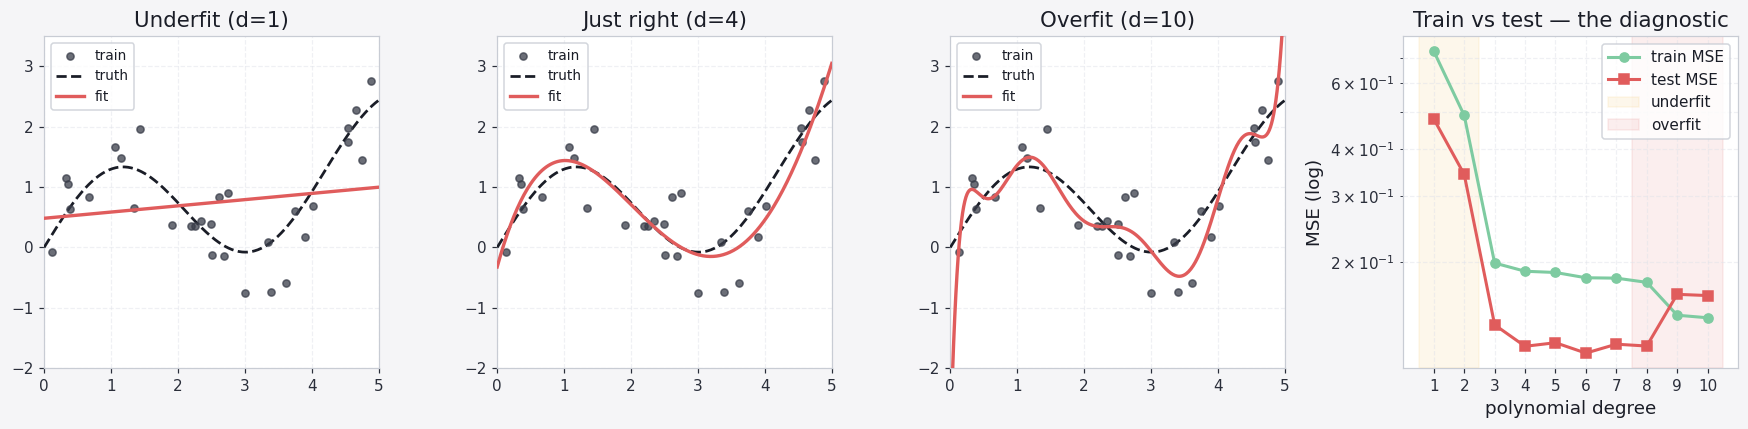

train MSE : ['0.727', '0.491', '0.199', '0.189', '0.187', '0.181', '0.181', '0.176', '0.144', '0.142']
test  MSE : ['0.480', '0.342', '0.136', '0.119', '0.122', '0.114', '0.121', '0.119', '0.164', '0.163']

Underfit (d=1):  train and test both high, gap small.
Just right (d=4): train and test both low, gap small.
Overfit (d=10): train near zero, test much larger - that gap IS overfitting.


In [41]:
from sklearn.metrics import mean_squared_error

X_train, y_train = make_dataset(7)
X_val,   y_val   = make_dataset(42)

train_err, val_err = [], []
fits = {}
for d in degs:
    m = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(X_train, y_train)
    train_err.append(mean_squared_error(y_train, m.predict(X_train)))
    val_err.append(  mean_squared_error(y_val,   m.predict(X_val)))
    if d in (1, 4, 10):
        fits[d] = m

fig, axes = plt.subplots(1, 4, figsize=(16, 4.0))
labels = {1: 'Underfit (d=1)', 4: 'Just right (d=4)', 10: 'Overfit (d=10)'}
xs = np.linspace(0, 5, 300)
for ax, d in zip(axes[:3], [1, 4, 10]):
    ax.scatter(X_train.ravel(), y_train, s=22, color='#3a3e4a',
               alpha=0.75, label='train', zorder=4)
    ax.plot(xs, f_true(xs), color='#1a1d27', lw=1.8, ls='--',
            label='truth', zorder=3)
    ax.plot(xs, fits[d].predict(xs[:, None]),
            color=PALETTE[1], lw=2.2, label='fit', zorder=5)
    ax.set_ylim(-2, 3.5); ax.set_xlim(0, 5)
    ax.set_title(labels[d]); ax.grid(True); ax.legend(loc='upper left', fontsize=9)

ax = axes[3]
ax.plot(degs, train_err, color=PALETTE[3], lw=2, marker='o', label='train MSE')
ax.plot(degs, val_err,   color=PALETTE[1], lw=2, marker='s', label='test MSE')
ax.set_yscale('log')
ax.set_xlabel('polynomial degree'); ax.set_ylabel('MSE (log)')
ax.set_title('Train vs test — the diagnostic'); ax.set_xticks(degs)
ax.axvspan(0.5, 2.5,  alpha=0.10, color=PALETTE[2], label='underfit')
ax.axvspan(7.5, 10.5, alpha=0.10, color=PALETTE[1], label='overfit')
ax.legend(); ax.grid(True, which='both')
plt.tight_layout(); plt.show()

print('train MSE :', [f'{e:.3f}' for e in train_err])
print('test  MSE :', [f'{e:.3f}' for e in val_err])
print()
print('Underfit (d=1):  train and test both high, gap small.')
print('Just right (d=4): train and test both low, gap small.')
print('Overfit (d=10): train near zero, test much larger - that gap IS overfitting.')


---
## Bias & Variance vary by algorithm — 2-feature example

The bias-variance trade-off plays out differently for each model family.
Using **2 features** lets us see everything as a 2D decision boundary.

**Setup:**
- **True boundary** = an ellipse (non-linear) — logistic regression with raw features can't fit this
- 2 features $x_1, x_2 \in [-2.2,\ 2.2]$, 40 independent training sets of 60 points each

**How to read the plots:**

| Visual element | What it means |
|---|---|
| Thin blue lines | Boundary from one training set = one $\hat{\theta}(\mathcal{D})$ |
| Spread / wobble of thin lines | **Variance** — $\hat{\theta}$ moves when training data changes |
| Green dashed line | **Average boundary** = $\mathbb{E}_\mathcal{D}[\hat{f}]$ (1st moment over training sets) |
| Black line | True boundary (ellipse) |
| Gap between green-dashed and black | **Bias** — systematic error even after averaging over all possible $\hat{\theta}$ |


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

n_bv_runs  = 40
n_bv_train = 60

def true_label_2d(X):
    """Class 1 inside ellipse, 0 outside."""
    return ((X[:, 0] - 0.1)**2 / 1.1**2 + (X[:, 1] + 0.05)**2 / 0.85**2 < 1).astype(int)

def make_2d_ds(seed, n=n_bv_train):
    r = np.random.RandomState(seed + 200)
    X = r.uniform(-2.2, 2.2, (n, 2))
    y = true_label_2d(X).copy()
    y[r.rand(n) < 0.05] ^= 1   # 5% label noise
    return X, y

# Evaluation grid
g = np.linspace(-2.2, 2.2, 70)
gx, gy = np.meshgrid(g, g)
Xg = np.c_[gx.ravel(), gy.ravel()]
yg_true = true_label_2d(Xg).astype(float)

algs = [
    ('LogReg (linear)',   LogisticRegression(max_iter=500)),
    ('LogReg (degree-2)', make_pipeline(PolynomialFeatures(2), LogisticRegression(max_iter=500))),
    ('Tree depth=1',      DecisionTreeClassifier(max_depth=1)),
    ('Tree depth=6',      DecisionTreeClassifier(max_depth=6)),
    ('KNN k=20',          KNeighborsClassifier(n_neighbors=20)),
    ('KNN k=1',           KNeighborsClassifier(n_neighbors=1)),
]

# Fit each algorithm on n_bv_runs independent training sets
grid_preds = {}
for name, clf in algs:
    preds = np.zeros((n_bv_runs, len(Xg)))
    for run in range(n_bv_runs):
        X_tr, y_tr = make_2d_ds(run)
        clf.fit(X_tr, y_tr)
        preds[run] = clf.predict_proba(Xg)[:, 1]
    grid_preds[name] = preds

print('Fitting complete — 6 algorithms × 40 training sets each.')


Fitting complete — 6 algorithms × 40 training sets each.


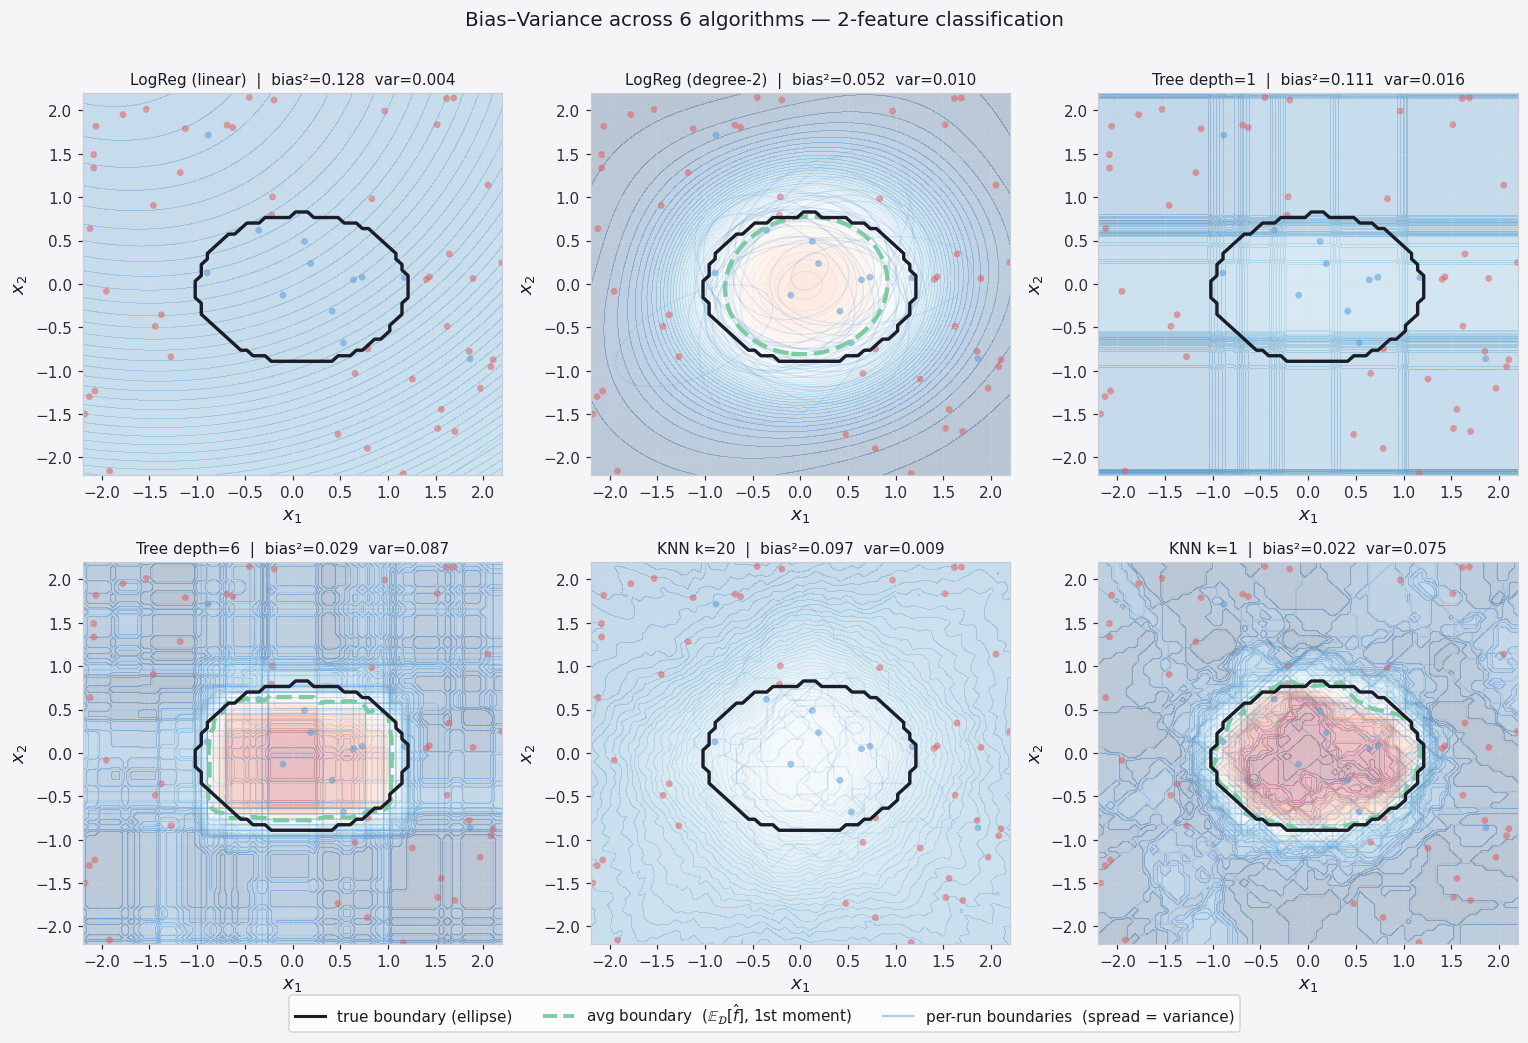

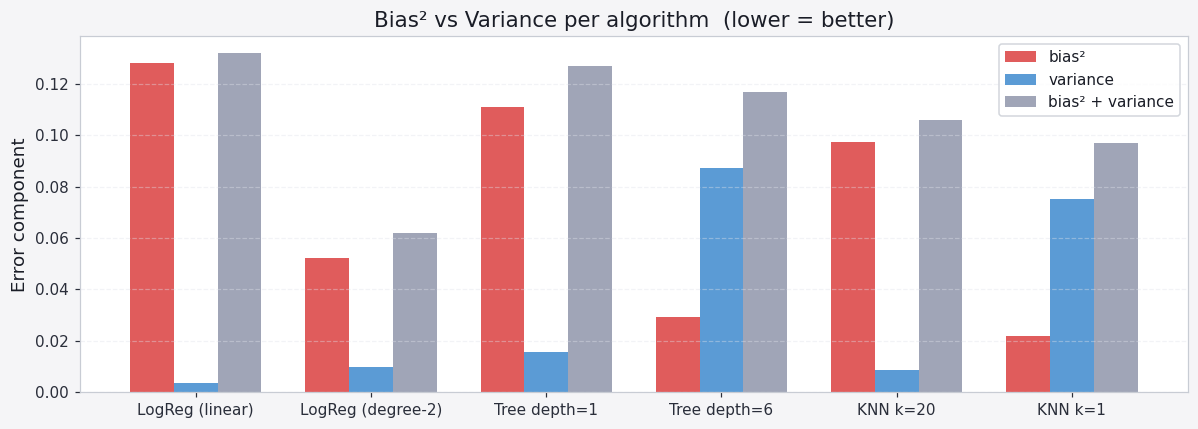

In [35]:
from matplotlib.lines import Line2D

X_sample, y_sample = make_2d_ds(0)

# ── 2×3 decision boundary panels ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
bv_vals = {}

for ax, (name, clf) in zip(axes.ravel(), algs):
    preds  = grid_preds[name]
    mean_p = preds.mean(axis=0)
    b2 = float(np.mean((mean_p - yg_true)**2))
    v  = float(np.mean(preds.var(axis=0)))
    bv_vals[name] = (b2, v)

    # Background: mean predicted probability (blue=class1, red=class0)
    ax.contourf(gx, gy, mean_p.reshape(gx.shape),
                levels=50, cmap='RdBu_r', alpha=0.28, vmin=0, vmax=1)

    # Per-run boundaries — spread shows variance
    for run in range(n_bv_runs):
        ax.contour(gx, gy, preds[run].reshape(gx.shape), levels=[0.5],
                   colors=[PALETTE[0]], alpha=0.18, linewidths=0.8)

    # Average boundary: 1st moment of predictions across all training sets
    ax.contour(gx, gy, mean_p.reshape(gx.shape), levels=[0.5],
               colors=[PALETTE[3]], linewidths=2.8, linestyles='--')

    # True boundary
    ax.contour(gx, gy, yg_true.reshape(gx.shape), levels=[0.5],
               colors=['#1a1d27'], linewidths=2.2)

    ax.scatter(X_sample[y_sample==1, 0], X_sample[y_sample==1, 1],
               color=PALETTE[0], s=20, alpha=0.55, edgecolors='none')
    ax.scatter(X_sample[y_sample==0, 0], X_sample[y_sample==0, 1],
               color=PALETTE[1], s=20, alpha=0.55, edgecolors='none')

    ax.set_title(f'{name}  |  bias²={b2:.3f}  var={v:.3f}', fontsize=10)
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.grid(True, alpha=0.25)

legend_els = [
    Line2D([0], [0], color='#1a1d27', lw=2,   label='true boundary (ellipse)'),
    Line2D([0], [0], color=PALETTE[3], lw=2.5, ls='--',
           label=r'avg boundary  ($\mathbb{E}_\mathcal{D}[\hat{f}]$, 1st moment)'),
    Line2D([0], [0], color=PALETTE[0], lw=1.5, alpha=0.5,
           label='per-run boundaries  (spread = variance)'),
]
fig.legend(handles=legend_els, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle('Bias–Variance across 6 algorithms — 2-feature classification', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary: grouped bar chart ───────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(11, 4))
names  = [n for n, _ in algs]
b2s    = [bv_vals[n][0] for n, _ in algs]
vs     = [bv_vals[n][1] for n, _ in algs]
totals = [b + v for b, v in zip(b2s, vs)]
x = np.arange(len(algs))
w = 0.25

ax.bar(x - w, b2s,    w, color=PALETTE[1], label='bias²')
ax.bar(x,     vs,     w, color=PALETTE[0], label='variance')
ax.bar(x + w, totals, w, color='#888fa5',  label='bias² + variance', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel('Error component')
ax.set_title('Bias² vs Variance per algorithm  (lower = better)')
ax.legend(fontsize=10); ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


In [36]:
import pandas as pd

rows = []
for name, _ in algs:
    b2, v = bv_vals[name]
    total = b2 + v
    rows.append({
        'Algorithm':      name,
        'Bias²':          round(b2,    4),
        'Variance':       round(v,     4),
        'Bias²+Variance': round(total, 4),
        'Dominant term':  'bias²' if b2 > v else 'variance',
    })

df = pd.DataFrame(rows).set_index('Algorithm')

# Highlight lowest value in each numeric column
def highlight_min(col):
    return ['background-color: #c8e6c9' if v == col.min() else '' for v in col]

df.style \
  .apply(highlight_min, subset=['Bias²', 'Variance', 'Bias²+Variance']) \
  .set_caption('Bias–Variance summary across algorithms (green = lowest in column)') \
  .format({'Bias²': '{:.4f}', 'Variance': '{:.4f}', 'Bias²+Variance': '{:.4f}'})


,Bias²,Variance,Bias²+Variance,Dominant term
Algorithm,,,,
LogReg (linear),0.1281,0.0038,0.1319,bias²
LogReg (degree-2),0.0523,0.0098,0.0621,bias²
Tree depth=1,0.1109,0.0158,0.1267,bias²
Tree depth=6,0.0295,0.0873,0.1167,variance
KNN k=20,0.0975,0.0085,0.1060,bias²
KNN k=1,0.0217,0.0751,0.0969,variance


---
## How to use the bias–variance table

The table tells you **why** your model is failing and **what to do next**.

### Step 1 — Read the dominant term

| Dominant term | Diagnosis | Your model is… |
|---|---|---|
| **bias² >> variance** | Underfitting | too simple to represent the true pattern |
| **variance >> bias²** | Overfitting | too flexible, chasing noise in the training set |
| **bias² ≈ variance** | At or near the sweet spot | well-matched to the data |

---

### Step 2 — Act on the diagnosis

**If bias² is high → reduce bias**
- Switch to a more expressive model family (e.g. LogReg linear → LogReg degree-2 → Tree)
- Add more informative features or feature interactions
- Reduce regularisation strength (smaller `C` in LogReg, deeper tree, smaller `k` in KNN)

**If variance is high → reduce variance**
- Add more training data — variance falls as $1/n$ for many models
- Increase regularisation (larger `C`, shallower tree, larger `k` in KNN)
- Use ensemble methods: bagging averages many high-variance models to cancel their noise
- Feature selection / dropout: fewer parameters = fewer ways to chase noise

**If both are high → hardest case**
- Often means the model family is fundamentally wrong for this problem
- Try a different architecture before tuning hyperparameters

---

### Step 3 — Use the total (bias² + variance) for model selection

The total is your **expected test error** (minus irreducible noise $\sigma^2$).
Cross-validation estimates this total without knowing the true $f$ — it is the practical tool when you can't run the simulation above on real data.

> Rule of thumb: among models with similar total error, prefer the one with **lower variance** — it generalises more reliably to new data distributions and is less sensitive to the size of your training set.

---

### Connecting back to the table above

| Algorithm | Dominant problem | What to do |
|---|---|---|
| LogReg (linear) | High bias² | Needs richer features — degree-2 expansion fixes it |
| LogReg (degree-2) | Low total | Sweet spot for this problem |
| Tree depth=1 | High bias² | Stump can only make one split — increase depth |
| Tree depth=6 | High variance | Memorises noise — prune, regularise, or add more data |
| KNN k=20 | Balanced | Smoothing over 20 neighbours keeps variance in check |
| KNN k=1 | High variance | Every point drives its own region — increase k |
